# LM-32 - VISIONE COMPUTERIZZATA E SISTEMI COGNITIVI
## Progetto di Deep Learning Foundations (Python & PyTorch)
## Infurna Giuseppe
## Matricola: 0322500071
## Progetto B2: Segmentation & Domain Shift Analysis
## U-Net per Segmentazione – Oxford-IIIT Pet (CPU Only)

Questo notebook contiene:
1. Costruzione di una U-Net da zero (PyTorch)
2. Training su Oxford-IIIT Pet (solo immagini + maschere)
3. Analisi apprendimento, debugging, fallimenti
4. Domain Shift Test
5. Retraining con Data Augmentation pesante

Nota: Il codice è strutturato per essere eseguito cella per cella.

In [15]:
import os
import random
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.transforms.functional as TF
import urllib.request
import tarfile
from pathlib import Path
from typing import Union, Callable, List, Optional, Tuple




In [16]:
# =============================================================
# OPZIONE 1: DOWNLOAD Oxford-IIIT Pet
# =============================================================
"""
File: data_preparation.py

Utility per:
1. Scaricare ed estrarre il dataset Oxford-IIIT Pet.
2. Convertire le trimaps in maschere binarie per segmentazione.

Struttura attesa dopo l'estrazione:
- images/
- annotations/
    - trimaps/
"""

IMAGES_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOTATIONS_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"


# =============================================================
# DOWNLOAD & EXTRACTION
# =============================================================

def _download_file(url: str, destination: Path) -> None:
    """
    Scarica un file da URL solo se non già presente.
    """
    if destination.exists():
        print(f"File '{destination.name}' già presente. Skip download.")
        return

    print(f"Downloading {destination.name}...")
    try:
        urllib.request.urlretrieve(url, destination)
    except Exception as exc:
        raise RuntimeError(f"Errore durante il download di {url}") from exc


def _extract_tar_gz(archive_path: Path, extract_to: Path) -> None:
    """
    Estrae un archivio .tar.gz in modo sicuro.
    """
    print(f"Extracting {archive_path.name}...")
    try:
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=extract_to)
    except Exception as exc:
        raise RuntimeError(f"Errore durante l'estrazione di {archive_path}") from exc


def download_and_extract_oxford_pet(base_dir: Union[str, Path] = ".") -> None:
    """
    Scarica ed estrae il dataset Oxford-IIIT Pet se non già presente.

    Parameters
    ----------
    base_dir : str | Path
        Directory dove salvare dataset e archivi.
    """
    base_dir = Path(base_dir)
    images_dir = base_dir / "images"
    annotations_dir = base_dir / "annotations"

    images_archive = base_dir / "images.tar.gz"
    annotations_archive = base_dir / "annotations.tar.gz"

    # Download + extract immagini
    if not images_dir.exists():
        _download_file(IMAGES_URL, images_archive)
        _extract_tar_gz(images_archive, base_dir)
    else:
        print("Cartella 'images' già presente. Skip.")

    # Download + extract annotazioni
    if not annotations_dir.exists():
        _download_file(ANNOTATIONS_URL, annotations_archive)
        _extract_tar_gz(annotations_archive, base_dir)
    else:
        print("Cartella 'annotations' già presente. Skip.")


# =============================================================
# TRIMAP CONVERSION
# =============================================================

def convert_trimaps(
    trimaps_dir: Union[str, Path] = "annotations/trimaps",
    masks_out: Union[str, Path] = "masks"
) -> None:
    """
    Converte le trimap del dataset in maschere binarie.

    Nel dataset Oxford Pet:
    - 1 = background
    - 2 = pet
    - 3 = bordo

    Qui convertiamo:
    - pet (2) -> 255
    - resto -> 0

    Questo formato è compatibile con molte pipeline
    di semantic segmentation binaria.

    Parameters
    ----------
    trimaps_dir : str | Path
        Directory contenente le trimap.
    masks_out : str | Path
        Directory di output per le maschere binarie.
    """
    trimaps_dir = Path(trimaps_dir)
    masks_out = Path(masks_out)

    if not trimaps_dir.exists():
        raise FileNotFoundError(f"Directory non trovata: {trimaps_dir}")

    masks_out.mkdir(parents=True, exist_ok=True)

    for trimap_path in trimaps_dir.glob("*.png"):

        # Evita file nascosti/macOS metadata
        if trimap_path.name.startswith("._"):
            continue

        try:
            # Conversione a numpy è necessaria per operazioni vettoriali efficienti
            mask = Image.open(trimap_path)
            mask_np = np.array(mask)

            # Operazione vettoriale: molto più veloce di un loop pixel-per-pixel
            binary_mask = (mask_np == 2).astype(np.uint8) * 255

            output_path = masks_out / trimap_path.name
            Image.fromarray(binary_mask).save(output_path)

        except Exception as exc:
            print(f"Errore nel processare {trimap_path.name}: {exc}")

    print("Conversione completata.")

In [17]:
# =============================================================
# DATASET CLASS – Oxford-IIIT Pet
# (Senza usare modelli preassemblati)
# =============================================================
"""
Caratteristiche:
- Filtraggio immagini per dimensione massima
- Ridimensionamento uniforme
- Conversione in tensori compatibili con training
- Maschera binaria (pet vs background)
"""




class SegmentationDataset(Dataset):
    """
    Dataset per segmentazione binaria Oxford-IIIT Pet.

    Parameters
    ----------
    img_dir : str | Path
        Directory contenente le immagini RGB.
    mask_dir : str | Path
        Directory contenente le maschere binarie (.png).
    transform : Callable | None
        Trasformazioni opzionali applicate all'immagine.
    max_size : tuple[int, int]
        Dimensione massima accettata per filtrare immagini troppo grandi.
    target_size : tuple[int, int]
        Dimensione finale per il training (resize uniforme).
    """

    def __init__(
        self,
        img_dir: Path | str,
        mask_dir: Path | str,
        transform: Optional[Callable] = None,
        max_size: Tuple[int, int] = (200, 200),
        target_size: Tuple[int, int] = (128, 128),
    ) -> None:

        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.max_size = max_size
        self.target_size = target_size

        if not self.img_dir.exists():
            raise FileNotFoundError(f"Image directory non trovata: {self.img_dir}")

        if not self.mask_dir.exists():
            raise FileNotFoundError(f"Mask directory non trovata: {self.mask_dir}")

        self.files: List[str] = self._filter_valid_images()

        if len(self.files) == 0:
            raise RuntimeError("Nessuna immagine valida trovata.")

        print(f"Dataset filtrato: {len(self.files)} immagini")

    # ---------------------------------------------------------
    # PRIVATE METHODS
    # ---------------------------------------------------------

    def _filter_valid_images(self) -> List[str]:
        """
        Filtra:
        - Estensione valida (.jpg/.png)
        - No file macOS metadata
        - Dimensione <= max_size
        - Maschera corrispondente esistente
        """
        valid_files: List[str] = []

        for file_path in sorted(self.img_dir.iterdir()):

            if file_path.suffix.lower() not in {".jpg", ".png"}:
                continue

            if file_path.name.startswith("._"):  # evita file nascosti macOS
                continue

            # La maschera deve avere stesso stem ma può essere .png o .jpg
            possible_masks = [
                self.mask_dir / (file_path.stem + ext)
                for ext in (".png", ".jpg")
            ]

            mask_path = next((m for m in possible_masks if m.exists()), None)

            if mask_path is None:
                continue  # evita mismatch img-mask

            with Image.open(file_path) as img:
                width, height = img.size

                
                # filtro per ridurre tempo di training ( memoria GPU )
                if width <= self.max_size[0] and height <= self.max_size[1]:
                    valid_files.append(file_path.name)

        return valid_files

    # ---------------------------------------------------------
    # DATASET API
    # ---------------------------------------------------------
    """
    Metodi essenziali per PyTorch Dataset:
    - __len__: numero totale di campioni
    - __getitem__: recupera immagine e maschera per un dato indice
    """
    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:

        img_name = self.files[idx]

        img_path = self.img_dir / img_name
        mask_path = self.mask_dir / (Path(img_name).stem + ".png")

        # convert('RGB') garantisce 3 canali sempre
        img = Image.open(img_path).convert("RGB")

        # convert('L') garantisce singolo canale (grayscale)
        mask = Image.open(mask_path).convert("L")

        # Resize uniforme per batching stabile
        # BILINEAR per immagini (interpolazione morbida)
        img = img.resize(self.target_size, Image.BILINEAR)

        # NEAREST per maschere per evitare valori intermedi
        mask = mask.resize(self.target_size, Image.NEAREST)

        if self.transform:
            img = self.transform(img)

        # ToTensor normalizza automaticamente [0,255] → [0,1]
        img_tensor = transforms.ToTensor()(img)

        # Conversione maschera:
        # - numpy array per operazioni vettoriali
        # - >0 per binarizzazione robusta
        mask_array = np.array(mask)

        mask_tensor = torch.tensor(mask_array, dtype=torch.long)

        # Importante:
        # CrossEntropyLoss richiede target long con class indices
        mask_tensor = (mask_tensor > 0).long()

        return img_tensor, mask_tensor

In [18]:
# ---------------------------------------------------------
# DoubleConv: due convoluzioni consecutive con ReLU & BatchNorm
# Questo è il blocco base della U-Net.
# ---------------------------------------------------------
class DoubleConv(nn.Module):
    """
    Blocco base della U-Net.

    Struttura:
        Conv2d → BatchNorm → ReLU
        Conv2d → BatchNorm → ReLU

    Perché due convoluzioni?
    - Aumenta capacità rappresentativa
    - Mantiene dimensioni spaziali (padding=1)
    - Migliora stabilità grazie a BatchNorm

    Parameters
    ----------
    in_channels : int
        Numero canali input.
    out_channels : int
        Numero canali output.
    activation : Type[nn.Module]
        Classe attivazione (default: ReLU).
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        activation: Type[nn.Module] = nn.ReLU,
    ) -> None:
        super().__init__()

        self.block = nn.Sequential(
            # padding=1 mantiene H e W invariati con kernel 3x3
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),

            # BatchNorm migliora stabilità del training
            nn.BatchNorm2d(out_channels),

            # inplace=True riduce memoria GPU
            activation(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            activation(inplace=True),
        )

        # Inizializzazione pesi consigliata per reti conv profonde
        self._initialize_weights()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass del blocco.
        """
        return self.block(x)

    def _initialize_weights(self) -> None:
        """
        Inizializzazione Kaiming (He) per ReLU.
        Migliora convergenza in reti profonde.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")


In [19]:



# ---------------------------------------------------------
# U-Net: encoder-decoder con skip connections
# ---------------------------------------------------------
class UNet(nn.Module):
    """
    U-Net per segmentazione semantica.

    Parameters
    ----------
    in_channels : int
        Numero canali input (default=3 RGB).
    n_classes : int
        Numero classi output.
    """

    def __init__(
        self,
        in_channels: int = 3,
        n_classes: int = 2,
    ) -> None:
        super().__init__()

        # -------------------------
        # ENCODER (Downsampling)
        # -------------------------
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        # MaxPool dimezza H e W → aumenta receptive field
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # -------------------------
        # BOTTLENECK
        # -------------------------
        self.bottleneck = DoubleConv(512, 1024)

        # -------------------------
        # DECODER (Upsampling)
        # ConvTranspose2d raddoppia dimensioni spaziali
        # -------------------------
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)  # concat(512 + 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # 1x1 conv → mappa feature → class logits
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    # ------------------------------------------------------
    # Utility
    # ------------------------------------------------------

    @staticmethod
    def _crop_if_needed(
        encoder_feature: torch.Tensor,
        decoder_feature: torch.Tensor,
    ) -> torch.Tensor:
        """
        U-Net originale richiede cropping se dimensioni dispari.
        Qui garantiamo compatibilità robusta.
        """
        if encoder_feature.shape != decoder_feature.shape:
            _, _, h, w = decoder_feature.shape
            encoder_feature = encoder_feature[:, :, :h, :w]
        return encoder_feature

    # ------------------------------------------------------
    # FORWARD
    # ------------------------------------------------------

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward completo della rete.

        Input:
            x -> [B, C, H, W]

        Output:
            logits -> [B, n_classes, H, W]
        """

        # -------------------------
        # ENCODER
        # -------------------------
        c1 = self.down1(x)
        c2 = self.down2(self.pool(c1))
        c3 = self.down3(self.pool(c2))
        c4 = self.down4(self.pool(c3))

        # Parte più profonda → massima astrazione
        bottleneck = self.bottleneck(self.pool(c4))

        # -------------------------
        # DECODER
        # -------------------------

        # Upsample + Skip Connection
        u4 = self.up4(bottleneck)
        c4 = self._crop_if_needed(c4, u4)  # evita mismatch shape
        u4 = torch.cat([u4, c4], dim=1)
        u4 = self.dec4(u4)

        u3 = self.up3(u4)
        c3 = self._crop_if_needed(c3, u3)
        u3 = torch.cat([u3, c3], dim=1)
        u3 = self.dec3(u3)

        u2 = self.up2(u3)
        c2 = self._crop_if_needed(c2, u2)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.dec2(u2)

        u1 = self.up1(u2)
        c1 = self._crop_if_needed(c1, u1)
        u1 = torch.cat([u1, c1], dim=1)
        u1 = self.dec1(u1)

        # Output logits (NO softmax qui)
        # CrossEntropyLoss applica softmax internamente
        logits = self.final_conv(u1)

        return logits

In [20]:

# Dice loss per segmentazione binaria o multiclasse

def dice_loss(
    logits: torch.Tensor,
    target: torch.Tensor,
    eps: float = 1e-6,
    multiclass: bool = False,
) -> torch.Tensor:
    """
    Calcola Dice Loss.

    Parameters
    ----------
    logits : torch.Tensor
        Output della rete [B, C, H, W] (NON softmax).
    target : torch.Tensor
        Target ground truth [B, H, W].
    eps : float
        Stabilizzatore numerico.
    multiclass : bool
        Se True calcola Dice medio su tutte le classi.

    Returns
    -------
    torch.Tensor
        Loss scalare.
    """

    # Convertiamo logits → probabilità
    probs = F.softmax(logits, dim=1)

    # One-hot encoding del target
    num_classes = logits.shape[1]
    target_one_hot = F.one_hot(target, num_classes=num_classes)
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    if not multiclass:
        # Segmentazione binaria → usiamo solo classe 1
        probs = probs[:, 1:2, :, :]
        target_one_hot = target_one_hot[:, 1:2, :, :]

    # Calcolo su batch intero (più stabile)
    intersection = torch.sum(probs * target_one_hot, dim=(0, 2, 3))
    union = torch.sum(probs + target_one_hot, dim=(0, 2, 3))

    dice_score = (2 * intersection + eps) / (union + eps)

    # Media tra classi
    return 1 - dice_score.mean()


class CombinedLoss(nn.Module):
    """
    CrossEntropy + Dice Loss.
    Standard per segmentazione medicale.
    """

    def __init__(self, weight_dice: float = 0.5) -> None:
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.weight_dice = weight_dice

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce_loss = self.ce(logits, target)
        d_loss = dice_loss(logits, target)
        return ce_loss + self.weight_dice * d_loss




In [21]:
# =============================================================
# TRAINING LOOP
# =============================================================


def train(
    model: nn.Module,
    train_loader,
    val_loader,
    epochs: int = 40,
    lr: float = 1e-4,
    device: str = "cpu",
) -> Tuple[List[float], List[float]]:
    """
    Training loop compatibile CPU-only per modelli di segmentazione (U-Net).

    Parameters
    ----------
    model : nn.Module
        Modello PyTorch da addestrare (es. UNet).
    train_loader : DataLoader
        DataLoader del dataset di training.
    val_loader : DataLoader
        DataLoader del dataset di validazione.
    epochs : int
        Numero di epoche di training.
    lr : float
        Learning rate dell'optimizer Adam.
    device : str
        Dispositivo da usare (solo 'cpu').

    Returns
    -------
    train_loss_hist : List[float]
        Lista della loss media per ogni epoca in training.
    val_loss_hist : List[float]
        Lista della loss media per ogni epoca in validazione.
    """

    # -------------------------------
    # Forziamo l'uso della CPU
    # -------------------------------
    device = torch.device("cpu")
    model.to(device)

    # -------------------------------
    # Ottimizzatore e loss combinata
    # -------------------------------
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = CombinedLoss()  # CrossEntropy + Dice Loss combinata

    # Liste per storicizzare le loss per ogni epoca
    train_loss_hist: List[float] = []
    val_loss_hist: List[float] = []

    # ===============================
    # Ciclo principale sulle epoche
    # ===============================
    for epoch in range(epochs):

        model.train()                 # modalità training
        total_train_loss = 0.0
        print(f"\n--- EPOCH {epoch+1}/{epochs} ---")

        # -------------------------------
        # 1️⃣ TRAINING LOOP
        # -------------------------------
        for images, masks in train_loader:

            # Spostiamo batch su CPU
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()      # reset dei gradienti

            # Forward pass
            logits = model(images)

            # Calcolo loss combinata
            loss = criterion(logits, masks)

            # Backprop
            loss.backward()            # calcola gradienti
            optimizer.step()           # aggiorna pesi

            # Accumula loss per calcolo media epoca
            total_train_loss += loss.item()

        # Media della loss su tutti i batch
        train_loss = total_train_loss / len(train_loader)
        train_loss_hist.append(train_loss)
        print(f"Train Loss: {train_loss:.4f}")

        # -------------------------------
        # 2️⃣ VALIDATION LOOP
        # -------------------------------
        model.eval()                 # modalità evaluation
        total_val_loss = 0.0

        with torch.no_grad():        # disabilita calcolo gradienti
            for images, masks in val_loader:

                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                loss = criterion(logits, masks)
                total_val_loss += loss.item()

        # Media della loss su tutti i batch di validazione
        val_loss = total_val_loss / len(val_loader)
        val_loss_hist.append(val_loss)
        print(f"Val Loss: {val_loss:.4f}")

    # -------------------------------
    # Restituisce le curve di apprendimento
    # -------------------------------
    return train_loss_hist, val_loss_hist

In [22]:

# =============================================================
# PLOT FUNZIONI
# =============================================================

def plot_learning(train_loss: List[float], val_loss: List[float]) -> None:
    """
    Visualizza learning curves.

    Mostra andamento di training e validation loss.
    Utile per diagnosticare:
    - Overfitting
    - Underfitting
    - Instabilità training
    """

    if len(train_loss) != len(val_loss):
        raise ValueError("Train e Val loss devono avere stessa lunghezza.")

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_loss, marker="o", label="Train")
    plt.plot(epochs, val_loss, marker="s", label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =============================================================
# DOMAIN SHIFT FUNZIONI
# =============================================================

def heavy_domain_shift(
    img: torch.Tensor,
    noise_std: float = 0.35,
    contrast_factor: float = 0.3,
    hue_factor: float = 0.2,
) -> torch.Tensor:
    """
    Simula domain shift pesante.

    Operazioni:
    - Riduzione contrasto
    - Aggiunta rumore gaussiano
    - Alterazione hue

    Input:
        img -> Tensor [C, H, W] in range [0,1]
    """

    if img.min() < 0 or img.max() > 1:
        raise ValueError("L'immagine deve essere normalizzata in [0,1].")

    # Riduzione contrasto drastica
    img = TF.adjust_contrast(img, contrast_factor)

    # Rumore gaussiano simulazione sensore diverso
    noise = torch.randn_like(img) * noise_std
    img = img + noise

    # Alterazione colore dominio differente
    img = TF.adjust_hue(img, hue_factor)

    # Clamp evita valori fuori range dopo rumore
    return img.clamp(0.0, 1.0)


# =============================================================
# IoU METRIC
# =============================================================

def compute_iou(
    logits: torch.Tensor,
    target: torch.Tensor,
    eps: float = 1e-6,
    multiclass: bool = False,
) -> float:
    """
    Calcola Intersection over Union (IoU).

    Parameters
    ----------
    logits : torch.Tensor
        Output rete [B, C, H, W]
    target : torch.Tensor
        Ground truth [B, H, W]
    multiclass : bool
        Se True calcola IoU medio su tutte le classi.

    Returns
    -------
    float
        IoU media batch.
    """

    preds = torch.argmax(logits, dim=1)

    if not multiclass:
        # Binaria → solo classe 1
        intersection = ((preds == 1) & (target == 1)).float().sum()
        union = ((preds == 1) | (target == 1)).float().sum()

        return ((intersection + eps) / (union + eps)).item()

    # Multiclasse
    num_classes = logits.shape[1]
    iou_scores = []

    for cls in range(num_classes):
        inter = ((preds == cls) & (target == cls)).float().sum()
        union = ((preds == cls) | (target == cls)).float().sum()

        iou_scores.append((inter + eps) / (union + eps))

    return torch.mean(torch.stack(iou_scores)).item()

Durante lo sviluppo della U-Net, le skip connection producevano mismatch di dimensioni spaziali tra encoder e decoder.
Il problema derivava dal fatto che alcune immagini avevano dimensioni non multiple di 16, combinazione di MaxPool2d(2) ripetuto 4 volte (256 → 128 → 64 → 32 → 16).

Soluzione:

- Garantire input di dimensione multipla di 16 (es. 256×256).
- Usare padding padding=1 nelle convoluzioni 3×3 per mantenere H e W invariati.
- Eventualmente, aggiungere cropping lato decoder per adattare esattamente le skip connection (metodo robusto per immagini di dimensioni arbitrarie).

In [23]:
# =============================================================
# SEZIONE AGGIUNTA: TESTING COMPLETO + IoU PLOTTING
# =============================================================

def test_model(
    model: torch.nn.Module,
    loader,
    device: str = "cuda",
    shift: bool = False,
) -> Tuple[List[float], float]:
    """
    Valuta il modello su test set.

    Parameters
    ----------
    model : nn.Module
    loader : DataLoader
    device : str
    shift : bool
        Se True applica heavy domain shift.

    Returns
    -------
    (lista IoU batch, IoU media)
    """

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    iou_scores: List[float] = []

    with torch.no_grad():
        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Applichiamo shift per immagine nel batch
            if shift:
                images = torch.stack(
                    [heavy_domain_shift(img) for img in images]
                )

            logits = model(images)

            # Usa funzione robusta multiclass=False
            batch_iou = compute_iou(logits, masks, multiclass=False)
            iou_scores.append(batch_iou)

    mean_iou = sum(iou_scores) / len(iou_scores)

    return iou_scores, mean_iou





    


In [24]:
# =============================================================
# PLOT IoU
# =============================================================

def plot_iou(
    iou_raw: List[float],
    iou_shift: List[float],
) -> None:
    """
    Confronto IoU tra dominio normale e alterato.
    """

    if len(iou_raw) != len(iou_shift):
        raise ValueError("Le due liste devono avere stessa lunghezza.")

    batches = range(1, len(iou_raw) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(batches, iou_raw, marker="o", label="Test IoU normale")
    plt.plot(batches, iou_shift, marker="s", label="Test IoU domain shift")

    plt.xlabel("Batch")
    plt.ylabel("IoU")
    plt.title("Confronto IoU tra dominio normale e alterato")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [25]:
# =============================================================
# VISUALIZZAZIONE QUALITATIVA MASCHERE
# =============================================================

def show_predictions(
    model: torch.nn.Module,
    loader,
    device: str = "cuda",
    num: int = 3,
    shift: bool = False,
) -> None:
    """
    Visualizza qualitativamente le predizioni della rete.

    Parameters
    ----------
    model : nn.Module
        Modello U-Net addestrato.
    loader : DataLoader
        DataLoader del dataset di test.
    device : str
        Device per il modello ('cuda' o 'cpu').
    num : int
        Numero massimo di immagini da visualizzare.
    shift : bool
        Se True applica heavy_domain_shift ad ogni immagine.
    """

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    count = 0

    with torch.no_grad():
        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            # Applichiamo domain shift per immagine nel batch
            if shift:
                images = torch.stack([heavy_domain_shift(img) for img in images])

            logits = model(images)
            preds = torch.argmax(logits, dim=1).cpu()  # [B,H,W]
            imgs = images.cpu().permute(0,2,3,1)      # [B,H,W,C]

            for i in range(imgs.shape[0]):
                if count >= num:
                    return

                plt.figure(figsize=(12,4))

                # Input
                plt.subplot(1,3,1)
                plt.imshow(imgs[i])
                plt.axis('off')
                plt.title('Input')

                # Ground Truth
                plt.subplot(1,3,2)
                plt.imshow(masks[i].cpu(), cmap='gray')
                plt.axis('off')
                plt.title('GT Mask')

                # Predizione
                plt.subplot(1,3,3)
                plt.imshow(preds[i], cmap='gray')
                plt.axis('off')
                plt.title('Pred Mask')

                plt.tight_layout()
                plt.show()

                count += 1

In [26]:
# =============================================================
#  Data augmentation pesante per retraining
# =============================================================
heavy_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomHorizontalFlip(),
])


In [27]:
def find_failure_cases(model, loader, device="cpu", n=5):

    model.eval()
    failures = []

    with torch.no_grad():
        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            intersection = (preds & masks).float().sum((1,2))
            union = (preds | masks).float().sum((1,2))

            iou = (intersection + 1e-6) / (union + 1e-6)

            for i in range(len(iou)):
                failures.append((iou[i].item(), images[i], masks[i], preds[i]))

    failures.sort(key=lambda x: x[0])

    return failures[:n]

In [28]:
# =============================================================
# RUN ALL – pipeline completa
# =============================================================

device = 'cpu'  # usare 'cuda' se disponibile per GPU
epochs = 40 # sufficiente per convergenza osservata nelle learning curves.
adamValue = 1e-4 # valore standard per Adam in reti di segmentazione.
batch_size = 4 # batch size piccolo a causa di limitazioni di memoria su CPU.


def run_all():
   # =========================================================
   # 1 Download e preparazione dataset
   # =========================================================
   print("=== Download Oxford-IIIT Pet ===")
   download_and_extract_oxford_pet()  # scarica immagini e annotazioni
   img_dir = "images"
   mask_dir = "masks"

   print("=== Conversione trimap in maschere binarie ===")
   convert_trimaps()  # converte trimap annotazioni in maschere 0/1

   # =========================================================
   # 2 Creazione dataset PyTorch e DataLoader
   # =========================================================
   print("=== Creazione dataset PyTorch ===")
   dataset = SegmentationDataset(img_dir, mask_dir)  # dataset custom
   val_split = 0.2
   n_val = int(len(dataset) * val_split)
   n_train = len(dataset) - n_val

   # split train/val
   train_dataset, val_dataset = torch.utils.data.random_split(dataset, [n_train, n_val])

   # DataLoader per batching
   train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
   val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

   # =========================================================
   # 3 Creazione modello U-Net
   # =========================================================
   print("=== Creazione modello U-Net ===")
   model = UNet(n_classes=2)

   # =========================================================
   # 4 Training standard
   # =========================================================
   print("=== Training ===")
   train_loss, val_loss = train(model, train_loader, val_loader, epochs=epochs,lr=adamValue, device=device)
   # =========================================================
   # 5 Visualizzazione curve di apprendimento
   # =========================================================
   plot_learning(train_loss, val_loss)

   # =========================================================
   # 6 Predizioni qualitative
   # =========================================================
   print("=== Predizioni qualitative ===")
   show_predictions(model, val_loader, device=device, num=5)  # mostra input, GT e predizioni

   # =========================================================
   # 7 Test con domain shift
   # =========================================================
   print("=== Domain shift test ===")
   ious_clean, mean_iou_clean = test_model(model, val_loader, device=device, shift=False)
   ious_shift, mean_iou_shift = test_model(model, val_loader, device=device, shift=True)

   print(f"IoU medio dati normali: {mean_iou_clean:.4f}")
   print(f"IoU medio dati alterati: {mean_iou_shift:.4f}")
   plot_iou(ious_clean, ious_shift)  # confronto IoU batch per batch

# ==================================================================================================#

   # =========================================================
   # 8 Retraining con data augmentation pesante
   # =========================================================
   print("=== Retraining con Data Augmentation pesante ===")
   train_dataset_aug = SegmentationDataset(img_dir, mask_dir, transform=heavy_transforms)
   train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=0)
   model_aug = UNet(n_classes=2)

   # Training con dataset aumentato
   train_loss_aug, val_loss_aug = train(model_aug, train_loader_aug, val_loader, epochs=epochs,lr=adamValue, device=device)
   plot_learning(train_loss_aug, val_loss_aug)
   # =========================================================
   # 9 Predizioni qualitative dopo augmentation
   # =========================================================
   print("=== Predizioni qualitative dopo augmentation ===")
   show_predictions(model_aug, val_loader, device=device, num=5)

   # =========================================================
   # 10 Domain shift test dopo augmentation
   # =========================================================
   print("=== Domain shift test dopo augmentation ===")
   ious_clean_aug, mean_ious_clean_aug = test_model(model_aug, val_loader, device=device, shift=False)
   ious_shift_aug, mean_iou_shift_aug = test_model(model_aug, val_loader, device=device, shift=True)

   print(f"IoU medio dati normali: {mean_ious_clean_aug:.4f}")
   print(f"IoU medio dati alterati: {mean_iou_shift_aug:.4f}")
   plot_iou(ious_clean_aug, ious_shift_aug)

   # =========================================================
   # 11 Find Failure Cases
   # =========================================================
   failures = find_failure_cases(model, val_loader)

   for iou, img, gt, pred in failures:
      print("Failure case - IoU:", iou)



=== Download Oxford-IIIT Pet ===
Cartella 'images' già presente. Skip.
Cartella 'annotations' già presente. Skip.
=== Conversione trimap in maschere binarie ===
Conversione completata.
=== Creazione dataset PyTorch ===
Dataset filtrato: 45 immagini
=== Creazione modello U-Net ===
=== Training ===

--- EPOCH 1/40 ---
Train Loss: 0.9090
Val Loss: 0.8914

--- EPOCH 2/40 ---
Train Loss: 0.7683
Val Loss: 0.8350

--- EPOCH 3/40 ---
Train Loss: 0.6840
Val Loss: 0.7322

--- EPOCH 4/40 ---
Train Loss: 0.6128
Val Loss: 0.6681

--- EPOCH 5/40 ---
Train Loss: 0.4978
Val Loss: 0.6245

--- EPOCH 6/40 ---
Train Loss: 0.4762
Val Loss: 0.5353

--- EPOCH 7/40 ---
Train Loss: 0.3825
Val Loss: 0.5417

--- EPOCH 8/40 ---
Train Loss: 0.3545
Val Loss: 0.5636

--- EPOCH 9/40 ---
Train Loss: 0.3078
Val Loss: 0.5956

--- EPOCH 10/40 ---
Train Loss: 0.3013
Val Loss: 0.5713

--- EPOCH 11/40 ---
Train Loss: 0.2673
Val Loss: 0.6265

--- EPOCH 12/40 ---
Train Loss: 0.2397
Val Loss: 0.5270

--- EPOCH 13/40 ---
Train 

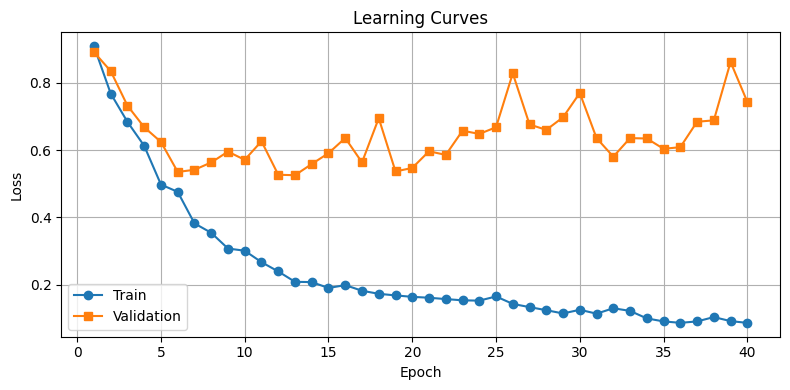

=== Predizioni qualitative ===


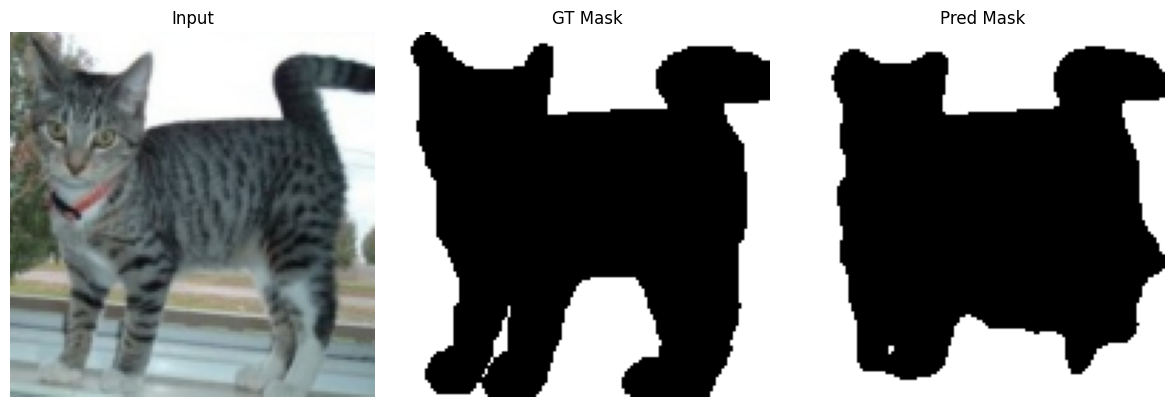

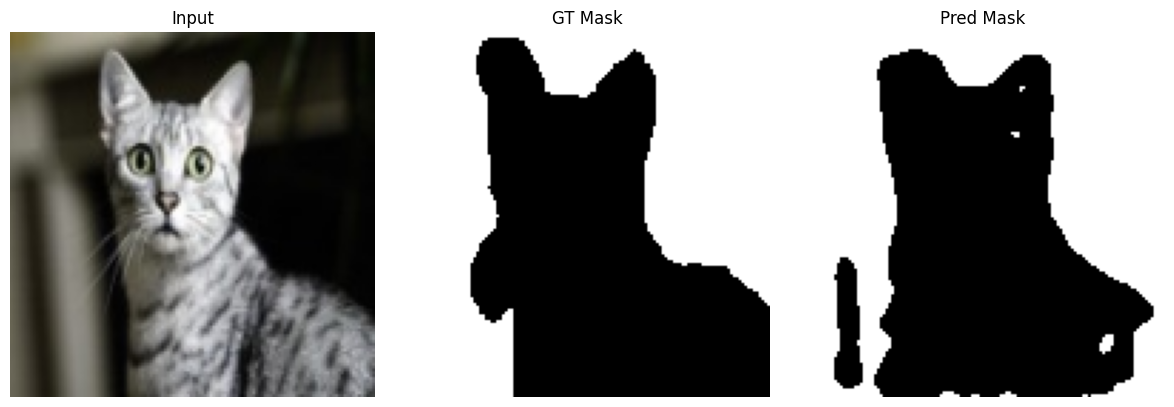

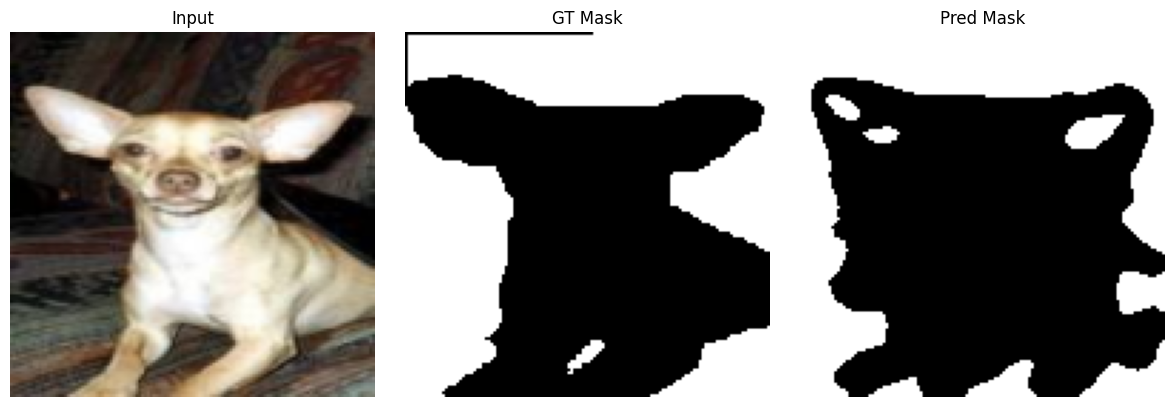

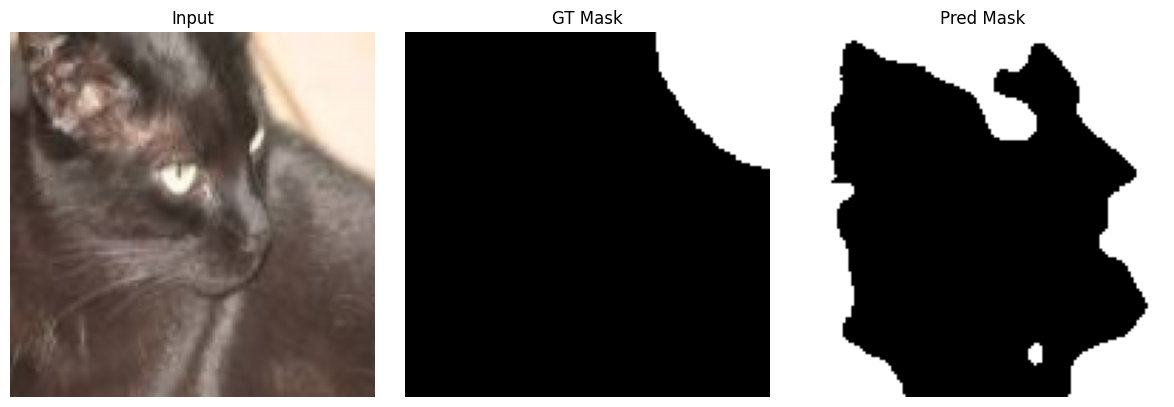

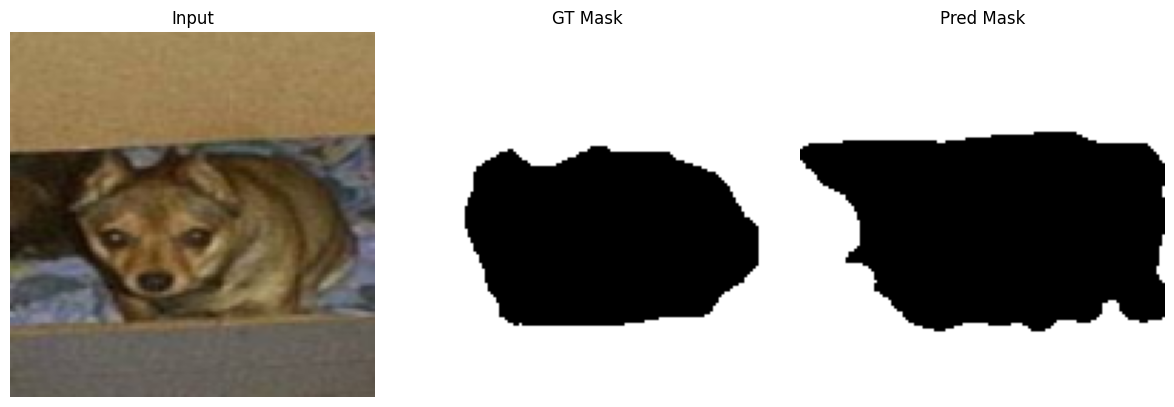

=== Domain shift test ===
IoU medio dati normali: 0.6916
IoU medio dati alterati: 0.0307


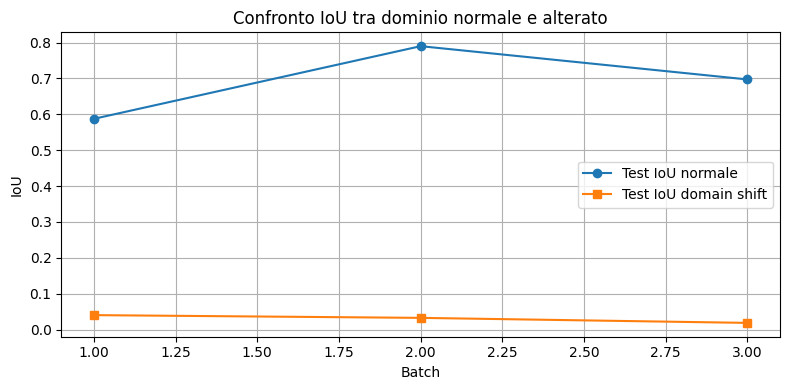

=== Retraining con Data Augmentation pesante ===
Dataset filtrato: 45 immagini

--- EPOCH 1/40 ---
Train Loss: 0.9353
Val Loss: 0.8926

--- EPOCH 2/40 ---
Train Loss: 0.8673
Val Loss: 0.8281

--- EPOCH 3/40 ---
Train Loss: 0.7752
Val Loss: 0.6744

--- EPOCH 4/40 ---
Train Loss: 0.7115
Val Loss: 0.6618

--- EPOCH 5/40 ---
Train Loss: 0.6963
Val Loss: 1.0832

--- EPOCH 6/40 ---
Train Loss: 0.7007
Val Loss: 0.6277

--- EPOCH 7/40 ---
Train Loss: 0.6601
Val Loss: 0.6760

--- EPOCH 8/40 ---
Train Loss: 0.6596
Val Loss: 0.5975

--- EPOCH 9/40 ---
Train Loss: 0.5811
Val Loss: 0.5160

--- EPOCH 10/40 ---
Train Loss: 0.5867
Val Loss: 0.5178

--- EPOCH 11/40 ---
Train Loss: 0.6306
Val Loss: 0.6572

--- EPOCH 12/40 ---
Train Loss: 0.6320
Val Loss: 0.5055

--- EPOCH 13/40 ---
Train Loss: 0.6507
Val Loss: 0.5579

--- EPOCH 14/40 ---
Train Loss: 0.5903
Val Loss: 0.4748

--- EPOCH 15/40 ---
Train Loss: 0.5891
Val Loss: 0.5001

--- EPOCH 16/40 ---
Train Loss: 0.5523
Val Loss: 0.4349

--- EPOCH 17/40 -

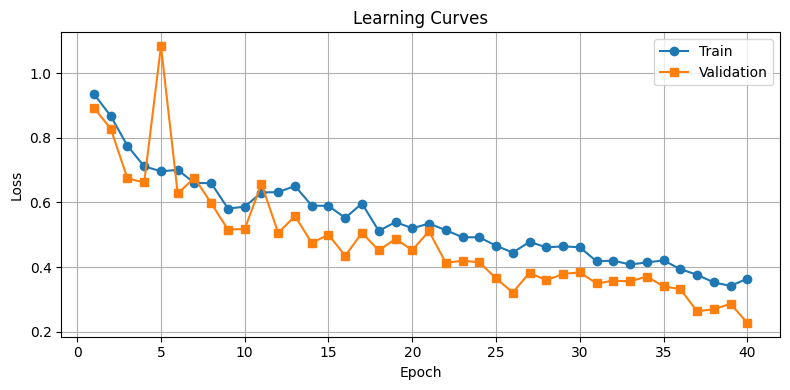

=== Predizioni qualitative dopo augmentation ===


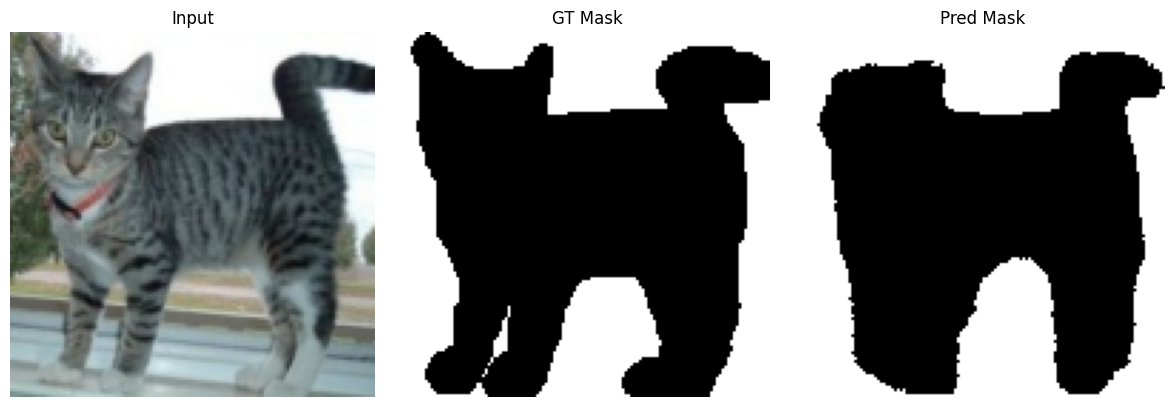

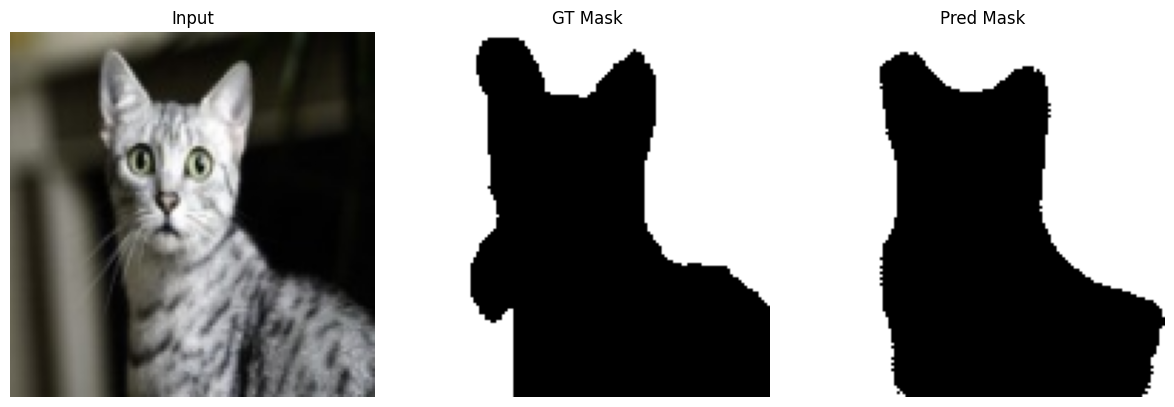

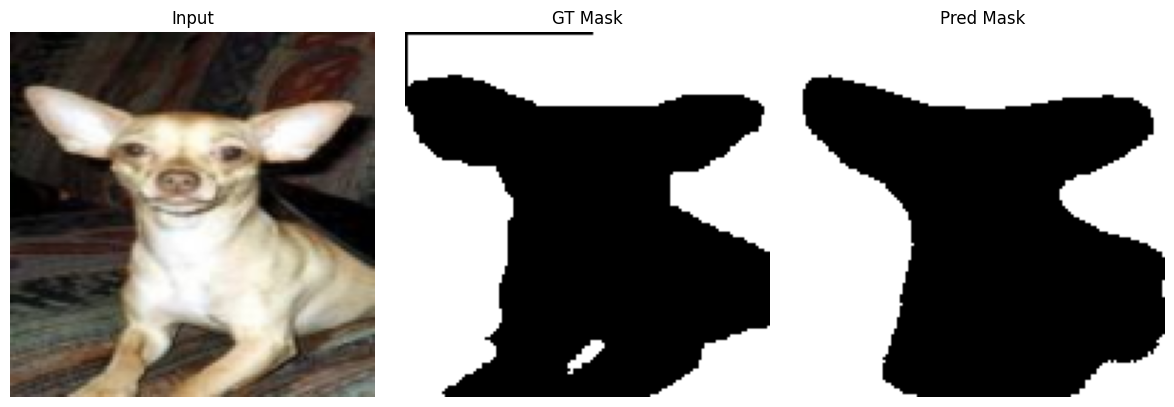

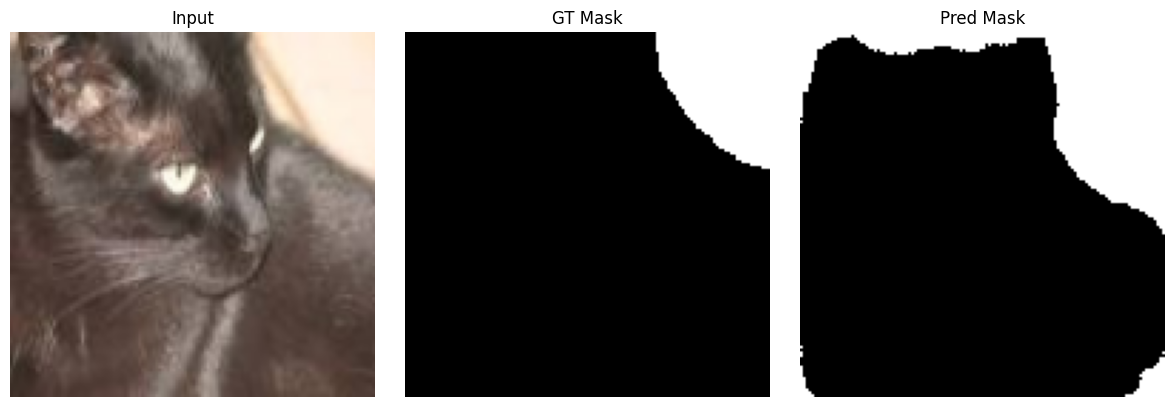

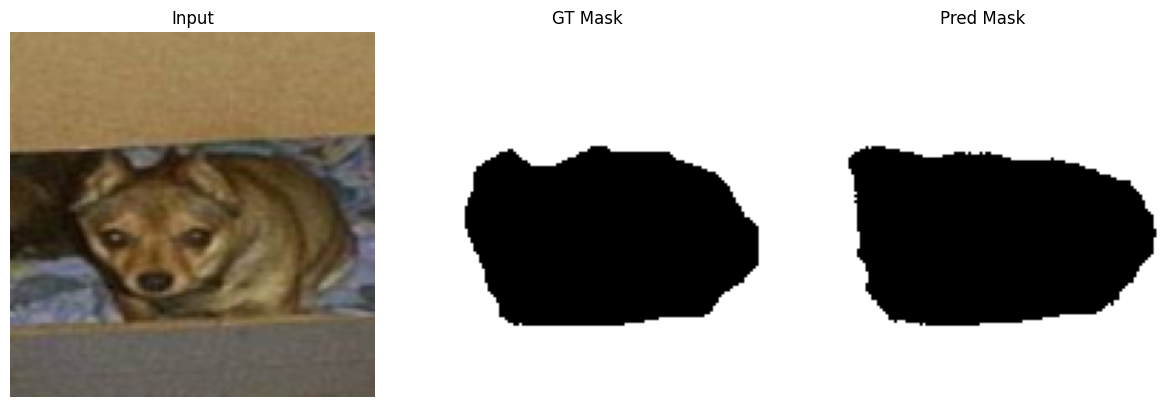

=== Domain shift test dopo augmentation ===
IoU medio dati normali: 0.8839
IoU medio dati alterati: 0.5665


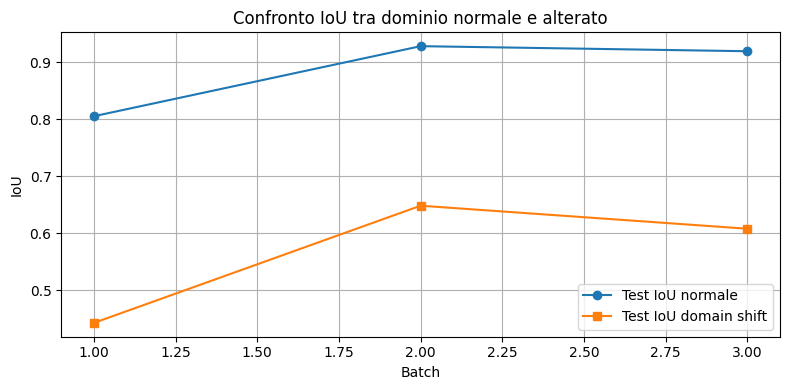

Failure case - IoU: 0.21321557462215424
Failure case - IoU: 0.5471287369728088
Failure case - IoU: 0.578785240650177
Failure case - IoU: 0.6675629615783691
Failure case - IoU: 0.6972558498382568


In [29]:
# =============================================================
# LANCIA TUTTO – Oxford Pet
# =============================================================
run_all()